In [2]:
import pandas as pd

df = pd.read_csv('../data/syntax_features.csv') 

In [3]:
df['word_count'] = df['Текст открытки'].fillna('').apply(lambda x: len(str(x).split()))
total_words = df['word_count'].sum()
total_words

74068

In [3]:
features = [
    'tree_depth', 'dep_distance', 'clauses', 'amod_chain',
    'advcl', 'participles', 'relcl', 'verbal_adverbs',
    'ccomp', 'infinitive_phrases', 'nmod'
]

feature_cols = [f'{feat}_mean' for feat in features if f'{feat}_mean' in df.columns]
 
stats = df[feature_cols].describe().T[['mean', 'std', 'min', 'max']].round(3)
stats.columns = ['Среднее', 'Ст. откл.', 'Минимум', 'Максимум']
stats.index = [idx.replace('_mean', '') for idx in stats.index]
stats

,Среднее,Ст. откл.,Минимум,Максимум
tree_depth,3.630,0.806,1.0,13.000
dep_distance,2.480,0.672,0.0,10.522
clauses,1.678,0.737,1.0,12.000
amod_chain,1.167,0.304,1.0,3.250
advcl,0.026,0.095,0.0,2.000
participles,0.017,0.097,0.0,3.000
relcl,0.013,0.064,0.0,1.000
verbal_adverbs,0.002,0.022,0.0,0.500
ccomp,0.028,0.090,0.0,1.000
infinitive_phrases,0.045,0.153,0.0,2.000


Описательные статистики для шкалы

In [4]:
stats = df['info_density_mean'].describe()
stats

count    1888.000000
mean        1.742301
std         0.802939
min         1.000000
25%         1.333333
50%         1.600000
75%         2.000000
max        12.000000
Name: info_density_mean, dtype: float64

Гистограмма распределения

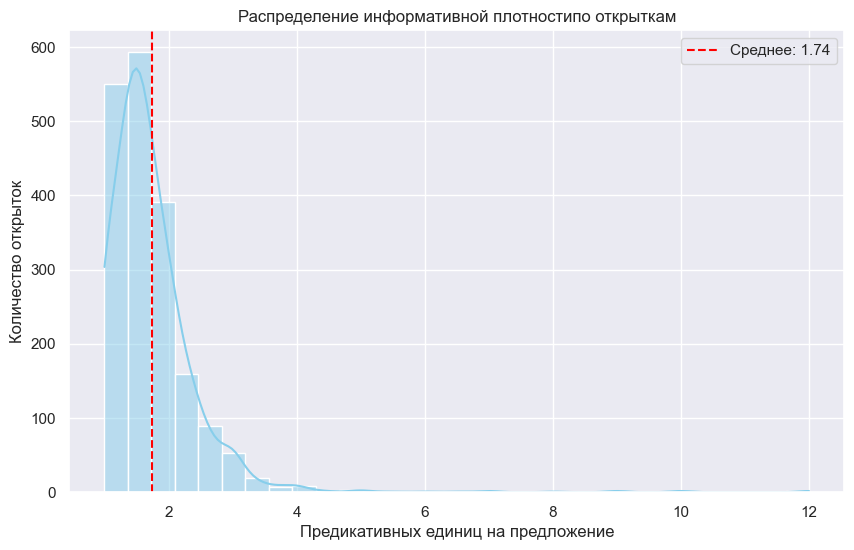

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['info_density_mean'], bins=30, kde=True, color='skyblue')
plt.title('Распределение информативной плотности по открыткам')
plt.xlabel('Предикативных единиц на предложение')
plt.ylabel('Количество открыток')
plt.axvline(df['info_density_mean'].mean(), color='red', linestyle='--', label=f'Среднее: {df["info_density_mean"].mean():.2f}')
plt.legend()
plt.show()

Классификация по уровням сложности

In [17]:
def complexity_level(x):
    if x < 1.5:
        return 'Очень низкий (1.0–1.5)'
    elif x < 2.5:
        return 'Низкий (1.5–2.5)'
    elif x < 4.0:
        return 'Средний (2.5–4.0)'
    elif x < 6.0:
        return 'Высокий (4.0–6.0)'
    else:
        return 'Очень высокий (>6.0)'

df['level'] = df['info_density_mean'].apply(complexity_level)

df['level'].value_counts().sort_index()

level
Высокий (4.0–6.0)          15
Низкий (1.5–2.5)          983
Очень высокий (>6.0)       11
Очень низкий (1.0–1.5)    711
Средний (2.5–4.0)         168
Name: count, dtype: int64

Примеры открыток из разных уровней

In [18]:
for level in df['level'].unique():
    sample = df[df['level'] == level].sample(1)
    print(f"\nУровень: {level}")
    print(f"ИП = {sample['info_density_mean'].values[0]:.2f}")
    print(f"Текст: {sample['Текст открытки'].values[0][:200]}...")


Уровень: Низкий (1.5–2.5)
ИП = 1.57
Текст: Здравствуйте наши дорогие папа, мама, Володя, Тамара, Сережа, Алеша! Поздравляем с Новым 1993 годом и с Рождеством! Желаем счастья, здоровья, всего хорошего. Целуем Витя, Нина, Володя, Андрей. Хотели ...

Уровень: Очень низкий (1.0–1.5)
ИП = 1.45
Текст: Дорогие друзья Михаил Григорьевич и Галя! Поздравляем С Новым годом! Опять шагает Новый год! Стучит ко всем в окно. Так пусть и Вас не обойдет! Здоровье, радость принесет! Пусть этот Новый год надежды...

Уровень: Средний (2.5–4.0)
ИП = 3.00
Текст: Дорогие родные Зина, Татьяна, Аня! Поздравляем вас с Новым годом! Желаем, чтоб Дед Мороз все невзгоды и печали в царство снежное унес. И принес бы вам здоровье, звон бокалов, шутки, смех, много радост...

Уровень: Высокий (4.0–6.0)
ИП = 4.00
Текст: Дорогая Лиличка! Поздравляю тебя с Новым 1997 годом! Желаю крепкого здоровья, любви и счастья, успехов во всем и везде, тепла, улыбок, веселья, добра и мира. Люда....

Уровень: Очень высокий (>6.0)
ИП = 9

Сравнение с другими признаками

Корреляция ИП с глубиной дерева: 0.609


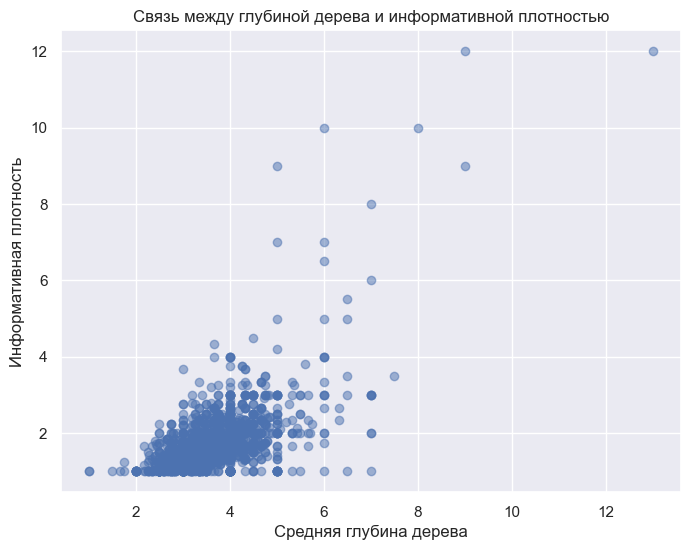

In [19]:
corr = df['info_density_mean'].corr(df['tree_depth_mean'])
print(f"Корреляция ИП с глубиной дерева: {corr:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(df['tree_depth_mean'], df['info_density_mean'], alpha=0.5)
plt.xlabel('Средняя глубина дерева')
plt.ylabel('Информативная плотность')
plt.title('Связь между глубиной дерева и информативной плотностью')
plt.show()